# 2.8 Gaussian city with relocations

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from city_simulator import City

# Integration test (no figures saved)

2025-10-10 09:58:21,830 - INFO - Initializing city
2025-10-10 09:58:21,831 - INFO - Calculating density profile for 1 core(s)
2025-10-10 09:58:21,845 - INFO - Running simulation for 5000 steps
2025-10-10 09:58:26,702 - INFO - Simulation completed in 4.86 seconds
2025-10-10 09:58:26,703 - INFO - In-simulation time passed: 17 days
2025-10-10 09:58:26,704 - INFO - Overall, statistics gathered over: 7 days
2025-10-10 09:58:26,705 - INFO - Cumulative rentals happened: 44685
2025-10-10 09:58:26,705 - INFO - Average rentals per car per day: 12.87
2025-10-10 09:58:26,706 - INFO - Average rental time per trip, min: 17.65
2025-10-10 09:58:26,707 - INFO - Average CM1 gain per trip, Eur: 4.41
2025-10-10 09:58:26,708 - INFO - Overall CM2 profit per day, Eur: 18398.79
2025-10-10 09:58:26,708 - INFO - Average relocations per day: 0.00


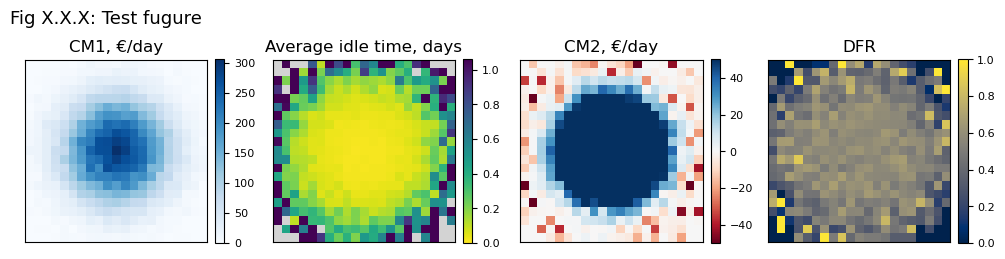

In [18]:
# Testing grounds, not a real figure
config = {
    "seed": 1,  # Random seed
    "initial_r": 5, # km
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "n_cars": 500,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
}

# To be able to re-run this one cell only, repeat package imports here
import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(5000)
plt.figure(figsize=(10, 5))
city.visualize(plots=["cm1", "idle_times", "cm2", "dfr"], title="Fig X.X.X: Test fugure")

In [4]:
stop_here()  # Intentional crash against "run all" overwriting everything

NameError: name 'stop_here' is not defined

# Typical stats - base state (no relocations, no price shenanigans, one core)

2025-10-10 09:51:30,146 - INFO - Initializing city
2025-10-10 09:51:30,148 - INFO - Calculating density profile for 1 core(s)
2025-10-10 09:51:30,157 - INFO - Running simulation for 10000 steps
2025-10-10 09:51:33,041 - INFO - ..Simulating step 5000 of 10000
2025-10-10 09:51:36,469 - INFO - Simulation completed in 6.31 seconds
2025-10-10 09:51:36,469 - INFO - In-simulation time passed: 35 days
2025-10-10 09:51:36,470 - INFO - Overall, statistics gathered over: 24 days
2025-10-10 09:51:36,470 - INFO - Cumulative rentals happened: 67135
2025-10-10 09:51:36,471 - INFO - Average rentals per car per day: 5.52
2025-10-10 09:51:36,471 - INFO - Average rental time per trip, min: 17.54
2025-10-10 09:51:36,472 - INFO - Average CM1 gain per trip, Eur: 4.38
2025-10-10 09:51:36,474 - INFO - Overall CM2 profit per day, Eur: 2108.22
2025-10-10 09:51:36,476 - INFO - Average relocations per day: 0.00
2025-10-10 09:51:36,759 - INFO - Initializing city
2025-10-10 09:51:36,760 - INFO - Calculating density

Creating a 2nd city now...


2025-10-10 09:51:41,104 - INFO - ..Simulating step 5000 of 10000
2025-10-10 09:51:45,330 - INFO - Simulation completed in 8.56 seconds
2025-10-10 09:51:45,333 - INFO - In-simulation time passed: 35 days
2025-10-10 09:51:45,334 - INFO - Overall, statistics gathered over: 24 days
2025-10-10 09:51:45,335 - INFO - Cumulative rentals happened: 69118
2025-10-10 09:51:45,336 - INFO - Average rentals per car per day: 5.69
2025-10-10 09:51:45,337 - INFO - Average rental time per trip, min: 17.47
2025-10-10 09:51:45,338 - INFO - Average CM1 gain per trip, Eur: 4.37
2025-10-10 09:51:45,339 - INFO - Overall CM2 profit per day, Eur: 2420.55
2025-10-10 09:51:45,340 - INFO - Average relocations per day: 12.47


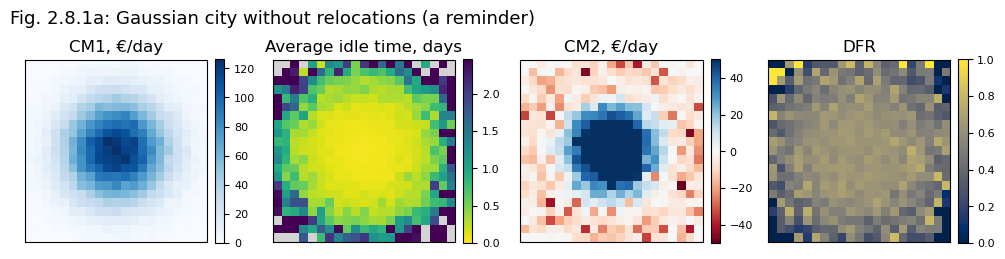

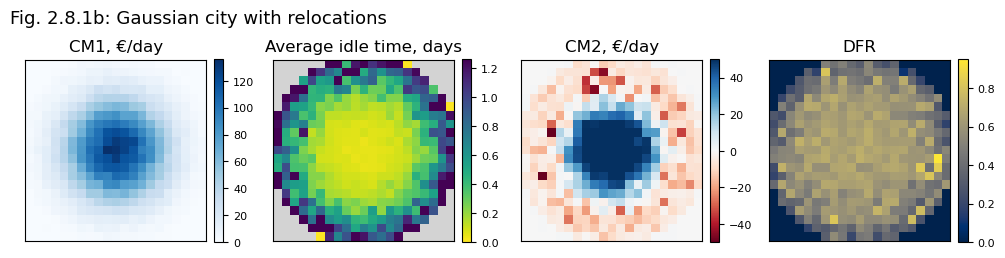

In [13]:
# Nice city
config = {
    "seed": 1,  # Random seed
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "n_cars": 500,
    "p_factor": 0.2, # Bring the rentals/car/day to about 4-5
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "do_flatten_demand": False,
    "do_relocations": False,
    "relo_cost": 10,
}

import numpy as np
import matplotlib.pyplot as plt
from city_simulator import City

city0 = City(config)
city0.init_cars()
city0.simulate(10000)

plt.figure(figsize=(10, 5))
city0.visualize(
    plots=["cm1", "idle_times", "cm2", "dfr"],
    title="Fig. 2.8.1a: Gaussian city without relocations (a reminder)"
)
# plt.savefig("../figures/02relos_08city_01control.svg", dpi=300)

print("Creating a 2nd city now...")
config["do_relocations"] = True
city1 = City(config)
city1.init_cars()
city1.simulate(10000)

plt.figure(figsize=(10, 5))
city1.visualize(
    plots=["cm1", "idle_times", "cm2", "dfr"],
    title="Fig. 2.8.1b: Gaussian city with relocations"
)
# plt.savefig("../figures/02relos_08city_02relocations.svg", dpi=300)

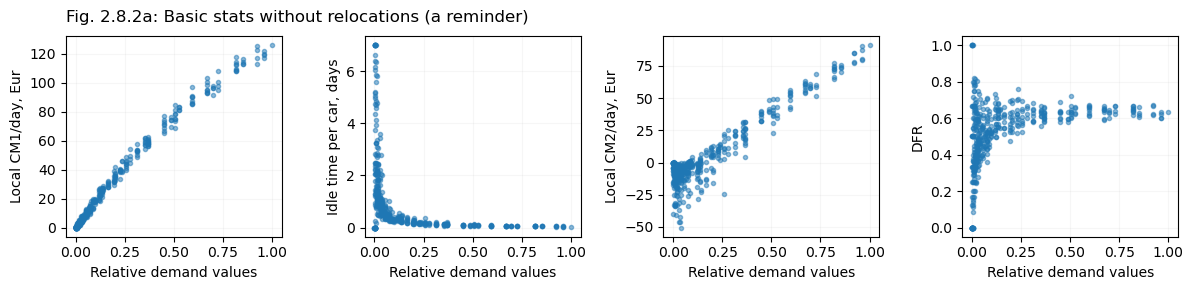

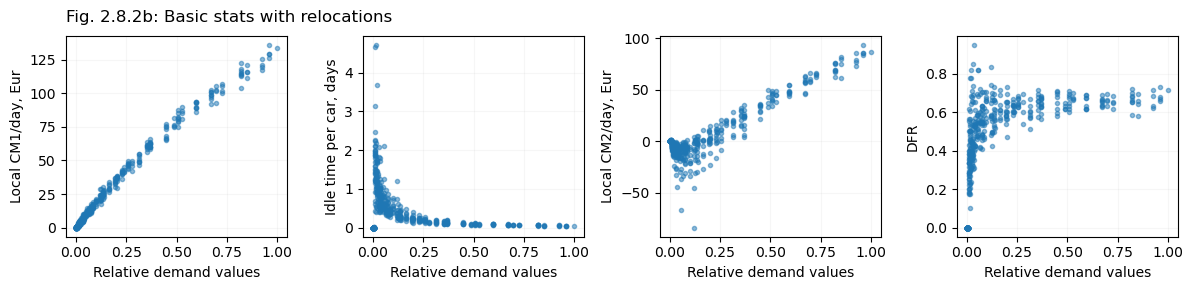

In [15]:
# Stats, use data from the previous run 👆

def extract_values(city):
    """Helper function to prep data for plots."""
    demand = city.demand.flatten()
    cm1 = city.map_cm1.flatten() / city.n_days
    cm2 = city.map_cm2.flatten() / city.n_days
    idle_times = city.map_idle_time.flatten() * city.tick_in_minutes / 60 / 24 / np.maximum(1, city.map_n_rentals.flatten())
    dfr = city.map_n_rentals.flatten() / np.maximum(1, city.map_n_appops.flatten())
    return demand, cm1, cm2, idle_times, dfr

def simple_stats_figure(city, title):
    demand, cm1, cm2, idle_times, dfr = extract_values(city)

    plt.figure(figsize=(12, 3))
    plt.subplot(141)
    plt.title(title, loc='left', pad=10);
    plt.plot(demand, cm1, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("Local CM1/day, Eur")

    plt.subplot(142)
    plt.plot(demand, np.minimum(7, idle_times), '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("Idle time per car, days")

    plt.subplot(143)
    plt.plot(demand, cm2, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("Local CM2/day, Eur")

    plt.subplot(144)
    plt.plot(demand, dfr, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("DFR")

    plt.tight_layout();

simple_stats_figure(city0, "Fig. 2.8.2a: Basic stats without relocations (a reminder)")
# plt.savefig("../figures/02relos_08city_03control_stats.svg", dpi=300)
simple_stats_figure(city1, "Fig. 2.8.2b: Basic stats with relocations")

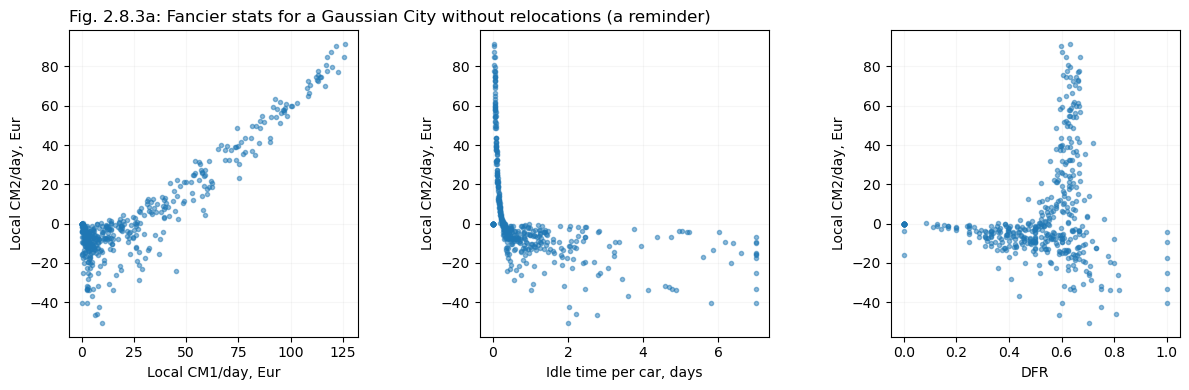

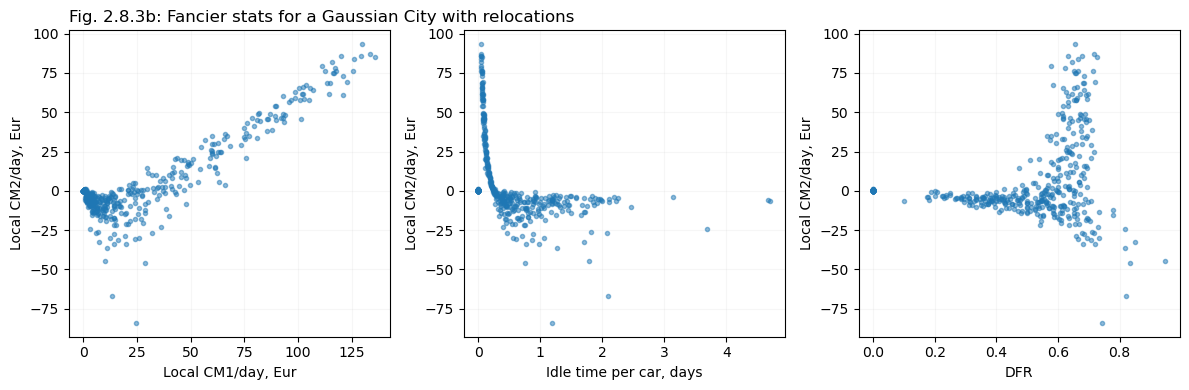

In [ ]:
# Fancier stats (from the same run)

def fancier_figure(city, title):
    demand, cm1, cm2, idle_times, dfr = extract_values(city)
    plt.figure(figsize=(12, 4))
    plt.subplot(131)
    plt.title(title, loc='left');
    plt.plot(cm1, cm2, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.ylabel("Local CM2/day, Eur")
    plt.xlabel("Local CM1/day, Eur")

    plt.subplot(132)
    plt.plot(np.minimum(idle_times, 7), cm2, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Idle time per car, days")
    plt.ylabel("Local CM2/day, Eur")

    plt.subplot(133)
    plt.plot(dfr, cm2, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("DFR")
    plt.ylabel("Local CM2/day, Eur")

    plt.tight_layout();

fancier_figure(city0, "Fig. 2.8.3a: Fancier stats for a Gaussian City without relocations (a reminder)")
fancier_figure(city1, "Fig. 2.8.3b: Fancier stats for a Gaussian City with relocations")
# plt.savefig("../figures/01simple_03city_06stats2_plots.svg", dpi=300)